<a href="https://colab.research.google.com/github/teejiayi99-droid/KQC-7016-Lab-2/blob/main/lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# LAB 2: Exploratory Data Analysis (EDA)
# Topic: An Analysis of the Relationship Between GDP and Oil Consumption Across Countries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler,LabelEncoder
from google.colab import drive
plt.style.use('seaborn-v0_8')
# 1. Mount Google Drive
drive.mount('/content/drive')

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/WorldEnergy.csv')

print("Shape:", df.shape)
print("First 5 rows:")
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (23195, 130)
First 5 rows:
         country  year iso_code  population  gdp  biofuel_cons_change_pct  \
0  ASEAN (Ember)  2000      NaN         NaN  NaN                      NaN   
1  ASEAN (Ember)  2001      NaN         NaN  NaN                      NaN   
2  ASEAN (Ember)  2002      NaN         NaN  NaN                      NaN   
3  ASEAN (Ember)  2003      NaN         NaN  NaN                      NaN   
4  ASEAN (Ember)  2004      NaN         NaN  NaN                      NaN   

   biofuel_cons_change_twh  biofuel_cons_per_capita  biofuel_consumption  \
0                      NaN                      NaN                  NaN   
1                      NaN                      NaN                  NaN   
2                      NaN                      NaN                  NaN   
3                      NaN                      NaN                  N

In [ ]:
# 2. CLEAN COLUMN NAMES

df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

gdp_col = "gdp"
oil_col = "oil_consumption"
year_col = "year"
country_col = "country"

print(f"Using columns → GDP: {gdp_col} | Oil: {oil_col} | Year: {year_col}")

Using columns → GDP: gdp | Oil: oil_consumption | Year: year


In [ ]:
# 3. FILTER & CLEAN DATA

# Keep only recent data
df = df[df[year_col] >= 2000].copy()

# Remove rows with missing OR zero values (IMPORTANT)
df = df.dropna(subset=[gdp_col, oil_col, 'population'])

df = df[
    (df[gdp_col] > 0) &
    (df[oil_col] > 0) &
    (df['population'] > 0)
]

# Remove countries with insufficient data (at least 15 years)
valid_countries = df.groupby(country_col).size()
valid_countries = valid_countries[valid_countries >= 15].index
df = df[df[country_col].isin(valid_countries)].copy()

print("After filtering:", df.shape)

After filtering: (1817, 130)


In [ ]:
# 4. FEATURE ENGINEERING WORKFLOW

# 4.1 Handle missing values
df = df.sort_values([country_col, year_col])
df[gdp_col] = df.groupby(country_col)[gdp_col].ffill().bfill()
df[oil_col] = df.groupby(country_col)[oil_col].ffill().bfill()

df[gdp_col] = df[gdp_col].fillna(df[gdp_col].median())
df[oil_col] = df[oil_col].fillna(df[oil_col].median())

In [ ]:
# 4.2 REMOVE OUTLIERS USING IQR

def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return data[(data[column] >= lower) & (data[column] <= upper)]

# Apply to key variables
df = remove_outliers_iqr(df, gdp_col)
df = remove_outliers_iqr(df, oil_col)

print("After outlier removal:", df.shape)

# Reduce skewness
df[gdp_col] = np.log1p(df[gdp_col])
df[oil_col] = np.log1p(df[oil_col])

After outlier removal: (1454, 130)


In [ ]:
# 4.3 Create derived feature
df['oil_per_capita'] = df[oil_col] / df['population'].replace(0, np.nan)
df['efficiency_proxy'] = df[gdp_col] / (df[oil_col] + 1)   # avoid division by zero

In [ ]:
# 4.4 Encode categorical
#     We use country as the categorical variable
le = LabelEncoder()
df['country_encoded'] = le.fit_transform(df[country_col])

In [ ]:
# 4.5 Normalize numeric columns
numeric_cols = [gdp_col, oil_col, 'oil_per_capita', 'efficiency_proxy']
scaler = MinMaxScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("\nFeature Engineering completed. Sample:")
print(df[[year_col, country_col, gdp_col, oil_col, 'oil_per_capita']].head())


Feature Engineering completed. Sample:
     year  country       gdp  oil_consumption  oil_per_capita
744  2000  Algeria  0.572012         0.554905        0.015192
745  2001  Algeria  0.584678         0.562452        0.015078
746  2002  Algeria  0.601911         0.584930        0.015227
747  2003  Algeria  0.621931         0.593540        0.015135
748  2004  Algeria  0.636908         0.603176        0.015048


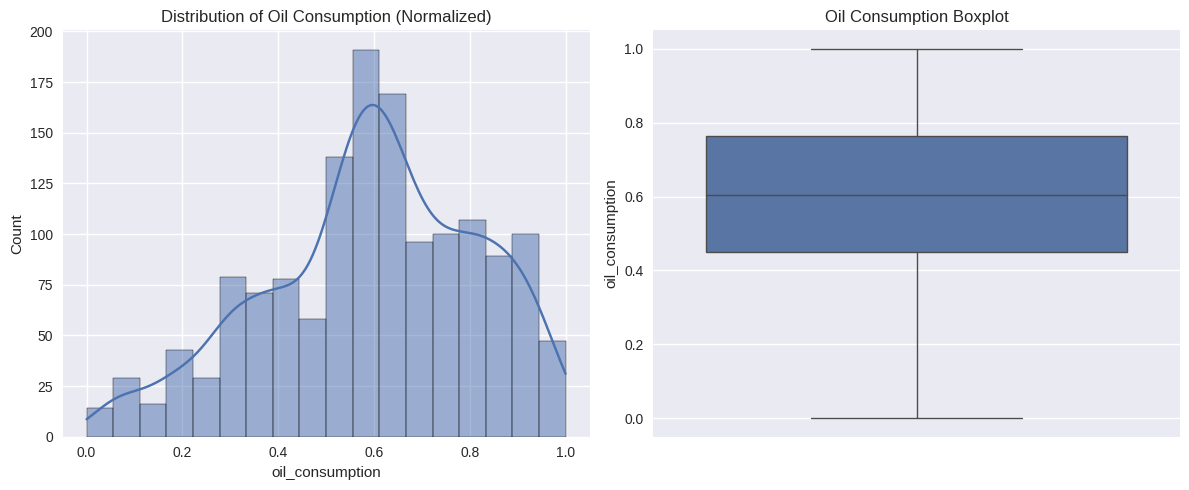

In [ ]:
# 5. VISUALIZATIONS

# 5.1 Univariate (Histogram + boxplot)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df[oil_col], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Oil Consumption (Normalized)")
sns.boxplot(y=df[oil_col], ax=axes[1])
axes[1].set_title("Oil Consumption Boxplot")
plt.tight_layout()
plt.show()

In [ ]:
# NEW: Create Region Column

region_map = {
    # Asia
    'China': 'Asia', 'India': 'Asia', 'Japan': 'Asia',
    'Malaysia': 'Asia', 'Indonesia': 'Asia', 'Thailand': 'Asia',

    # Europe
    'Germany': 'Europe', 'France': 'Europe', 'United Kingdom': 'Europe',
    'Italy': 'Europe', 'Spain': 'Europe',

    # North America
    'United States': 'North America', 'Canada': 'North America', 'Mexico': 'North America',

    # South America
    'Brazil': 'South America', 'Argentina': 'South America',

    # Africa
    'Nigeria': 'Africa', 'South Africa': 'Africa', 'Egypt': 'Africa',

    # Oceania
    'Australia': 'Oceania', 'New Zealand': 'Oceania'
}

df['region'] = df[country_col].map(region_map)

# Remove rows without region
df_region = df.dropna(subset=['region']).copy()

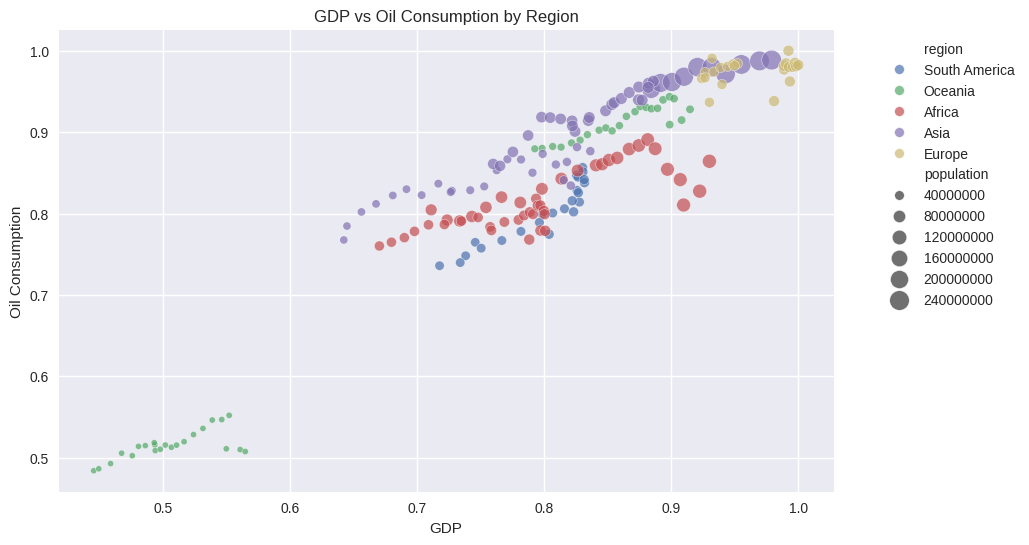

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_region,
    x=gdp_col,
    y=oil_col,
    hue='region',          # ✅ region instead of country
    size='population',     # ✅ 3rd variable
    sizes=(20, 200),
    alpha=0.7
)

plt.title("GDP vs Oil Consumption by Region")
plt.xlabel("GDP")
plt.ylabel("Oil Consumption")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')

plt.show()

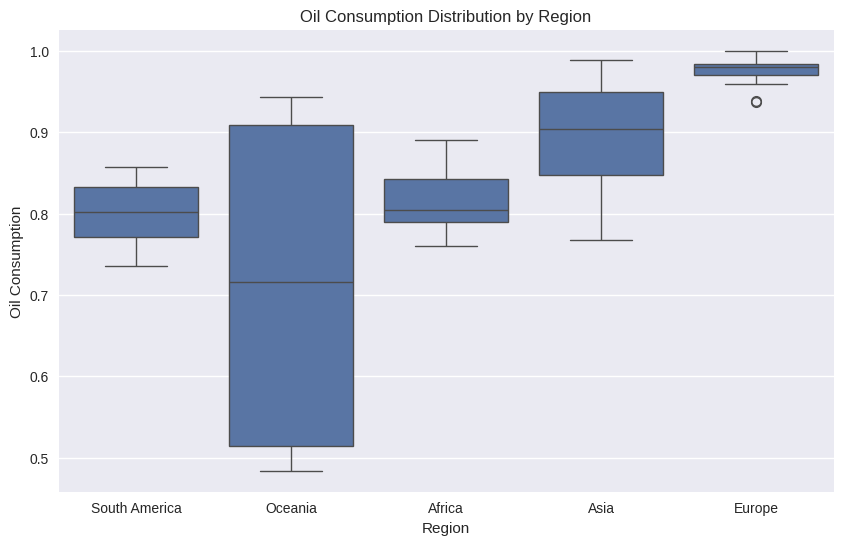

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_region,
    x='region',
    y=oil_col
)

plt.title("Oil Consumption Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Oil Consumption")

plt.show()

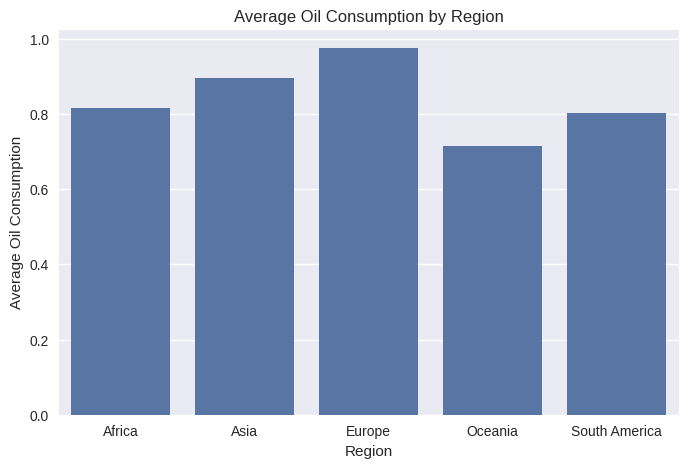

In [ ]:
region_avg = df_region.groupby('region')[oil_col].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=region_avg, x='region', y=oil_col)

plt.title("Average Oil Consumption by Region")
plt.xlabel("Region")
plt.ylabel("Average Oil Consumption")

plt.show()

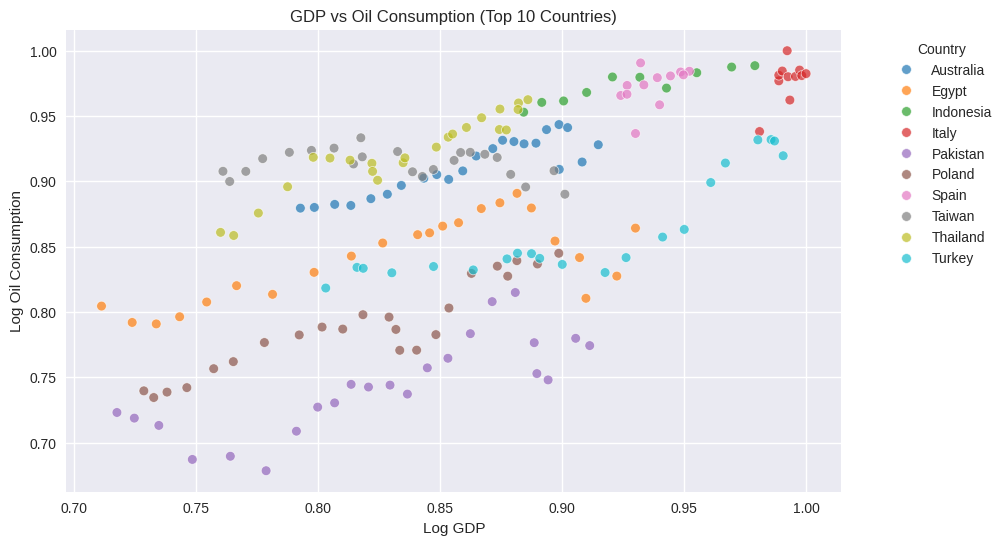

In [ ]:
# 5.2 Scatterplot

# Select top 10 countries by average GDP
top_countries = df.groupby(country_col)[gdp_col].mean().nlargest(10).index

df_top = df[df[country_col].isin(top_countries)]

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_top,
    x=gdp_col,
    y=oil_col,
    hue=country_col,   # use country names directly
    palette="tab10",
    alpha=0.7
)

plt.title("GDP vs Oil Consumption (Top 10 Countries)")
plt.xlabel("Log GDP")
plt.ylabel("Log Oil Consumption")
plt.legend(title="Country", bbox_to_anchor=(1.05,1), loc='upper left')

plt.show()

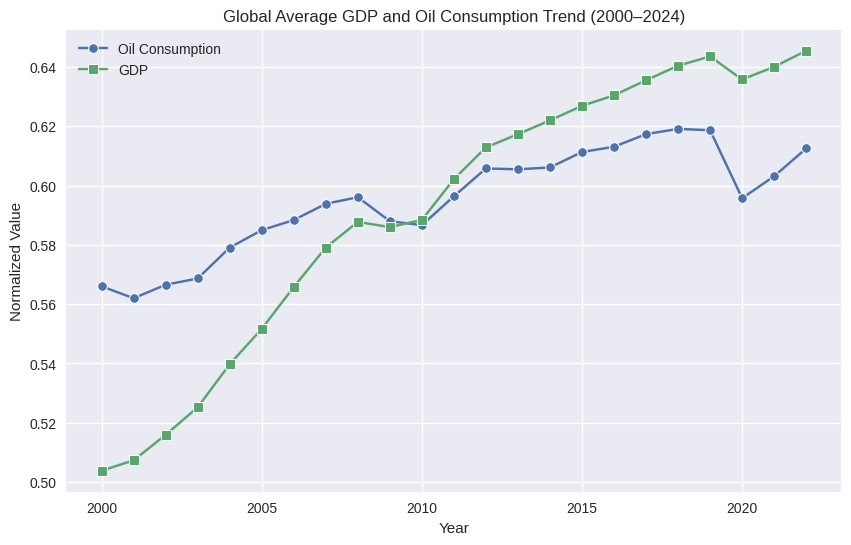

In [ ]:
# 5.3 Trend over time (global average)
yearly = df.groupby(year_col)[[oil_col, gdp_col]].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(data=yearly, x=year_col, y=oil_col, label="Oil Consumption", marker='o')
sns.lineplot(data=yearly, x=year_col, y=gdp_col, label="GDP", marker='s')
plt.title("Global Average GDP and Oil Consumption Trend (2000–2024)")
plt.xlabel("Year")
plt.ylabel("Normalized Value")
plt.legend()
plt.show()

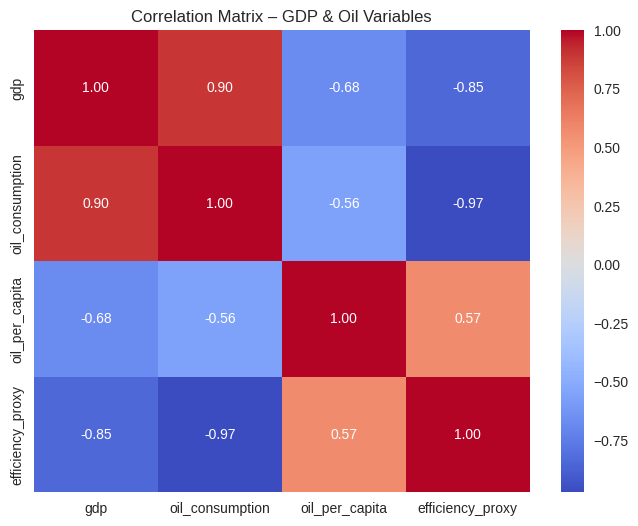

In [ ]:
# 5.4 Correlation Heatmap
plt.figure(figsize=(8, 6))
corr = df[[gdp_col, oil_col, 'oil_per_capita', 'efficiency_proxy']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix – GDP & Oil Variables")
plt.show()

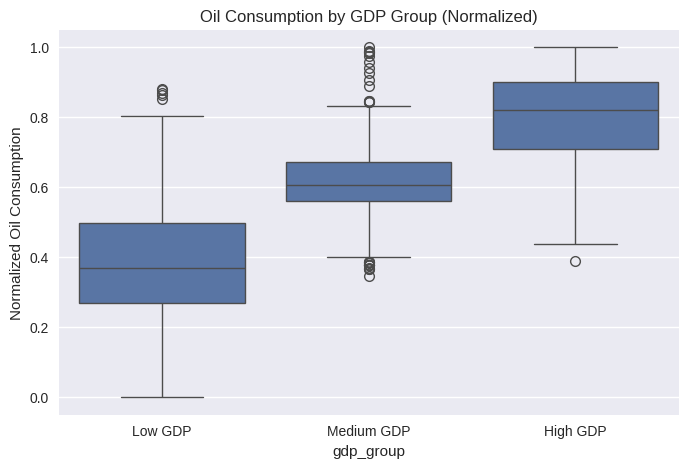

In [ ]:
# 5.5 Boxplot by GDP Group
df['gdp_group'] = pd.qcut(df[gdp_col], q=3, labels=['Low GDP', 'Medium GDP', 'High GDP'])

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='gdp_group', y=oil_col)
plt.title("Oil Consumption by GDP Group (Normalized)")
plt.ylabel("Normalized Oil Consumption")
plt.show()


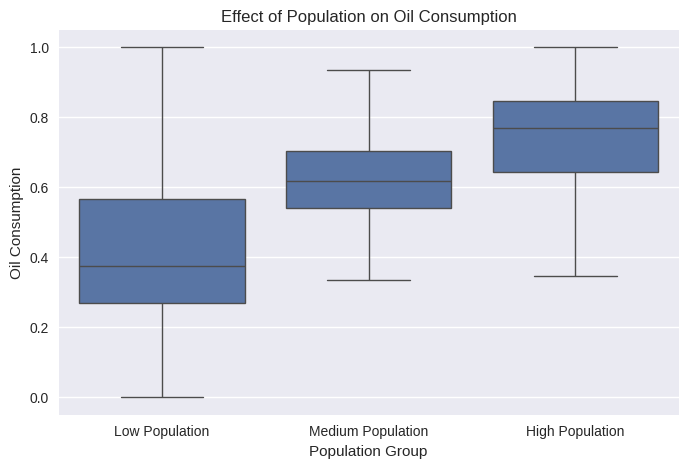

In [ ]:
# Create population groups (Low / Medium / High)
df['population_group'] = pd.qcut(
    df['population'],
    q=3,
    labels=['Low Population', 'Medium Population', 'High Population']
)

# Population Effect on Oil Consumption

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='population_group',
    y=oil_col
)

plt.title("Effect of Population on Oil Consumption")
plt.xlabel("Population Group")
plt.ylabel("Oil Consumption")

plt.show()

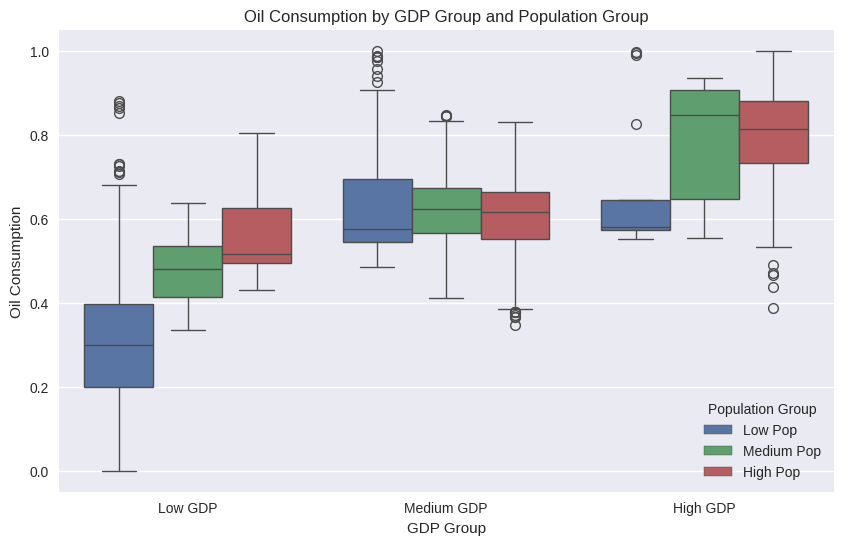

In [ ]:
# 5.5 Boxplot by GDP Group
df['gdp_group'] = pd.qcut(df[gdp_col], q=3, labels=['Low GDP', 'Medium GDP', 'High GDP'])
df['population_group'] = pd.qcut(
    df['population'],
    q=3,
    labels=['Low Pop', 'Medium Pop', 'High Pop']
)
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='gdp_group',
    y=oil_col,
    hue='population_group'
)

plt.title("Oil Consumption by GDP Group and Population Group")
plt.xlabel("GDP Group")
plt.ylabel("Oil Consumption")
plt.legend(title="Population Group")

plt.show()